# Exploratory Data Analysis

**Working notes. Descriptive groundwork for the formal models in `05_analysis`; no hypothesis is tested here.**

## What this notebook does

This notebook inspects the cleaned tables from `data/03_cleaning/` before any modeling, so the nine planned fits (three metrics x three event types) rest on data whose shape and coding we have actually seen. Exploratory data analysis (EDA) here is diagnostic, not inferential: it describes the data and surfaces problems that would distort a model, and it stops short of the year-10 test itself.

The design (see `CLAUDE.md`) analyzes three event types separately, never pooled, because they have different base rates and detection difficulty:
- **SV** severe thunderstorm
- **FF** flash flood
- **TO** tornado

And three performance metrics, each its own model:
1. **POD (probability of detection)** logistic on storm-report rows; outcome `warned`. Higher is better.
2. **FAR (false alarm ratio)** logistic on warning rows; outcome `verify`. FAR is `1 - verify`, so higher is worse.
3. **LTA (lead time)** ordinary least squares (OLS) on warned storm reports only; outcome `leadtime` in minutes. Higher is better.

## What we check here

- **Data shape and provenance.** Row counts, the two source tables (local storm reports (LSRs) for POD and LTA, warnings for FAR), and that the event-matching `params` are identical across all ten years.
- **Coding and dtypes.** `warned` and `verify` are integer 0/1; `study_year` is numeric 1-10; `season_cat` is the four text labels; `is_year10` is 0/1 derived from `study_year`. Re-checked after load, per the data prerequisites.
- **Rates and cells.** Per-`lsrtype`/`phenomena` outcome means, per-`season_cat` counts, and thin-cell or separation checks (a 0% or 100% cell prevents estimation).
- **Missingness.** No unhandled NaNs in modeled columns; anything dropped is reported, not silently dropped by the library.
- **Distributions and variability.** The shape of the LTA outcome and the baseline year-to-year variability of each metric, to calibrate what a year-10 departure would have to clear.

## Setup

Loads the two cleaned tables (`stormreports` for POD and LTA, `events` for FAR) and re-checks the modeled columns immediately after load: `study_year` numeric, `season_cat` text, and the 0/1 outcome and indicator columns. Per the data prerequisites, we do not trust the CSV dtype blindly; we assert it here so a coding regression fails loudly before any plot or fit.

In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.api.types import is_numeric_dtype

from src.analysis.constants import (PHENOMENA, PHENOMENA_LABELS, PHENOMENA_COLORS,
                                    LSR_SIZES, CONUS_XLIM, CONUS_YLIM)
from src.analysis.data import load_events, load_stormreports, load_states, load_wfo_coords
from src.analysis import plots

# Plot styling: matplotlib-native whitegrid (shared with 05_analysis)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120

CLEAN_DIR = Path("../data/03_cleaning")
GEO_DIR   = Path("../data/geo")   # regenerable Census caches (state outlines, ZCTA fallback)
WFO_DIR   = Path("../data/wfo")   # tracked office inputs (wfo_list.csv, wfo_coords.csv)
IMG_DIR   = Path("../img")
IMG_DIR.mkdir(exist_ok=True)

# stormreports (one row per LSR) carries POD and LTA; events (one row per warning) carries FAR.
stormreports = load_stormreports(CLEAN_DIR)
events       = load_events(CLEAN_DIR)

SEASON_CATS = ["Spring", "Summer", "Fall", "Winter"]

# Re-check coding after load; fail loudly before any plot or fit (per CLAUDE.md prerequisites).
def check_coding():
    for df, name in [(stormreports, "stormreports"), (events, "events")]:
        assert is_numeric_dtype(df["study_year"]), f"{name}.study_year must be numeric"
        sy = df["study_year"]
        assert sy.between(1, 10).all(), f"{name}.study_year outside 1-10"
        assert set(df["season_cat"].unique()) <= set(SEASON_CATS), f"{name}.season_cat has unexpected labels"
        # is_year10 is exactly the year-10 indicator, coded 0/1
        assert (df["is_year10"] == (sy == 10).astype(int)).all(), f"{name}.is_year10 != (study_year == 10)"
        assert set(df["is_year10"].unique()) <= {0, 1}, f"{name}.is_year10 not 0/1"
    assert set(stormreports["warned"].dropna().unique()) <= {0, 1}, "stormreports.warned not 0/1"
    assert set(events["verify"].dropna().unique()) <= {0, 1}, "events.verify not 0/1"

check_coding()

print(f"stormreports : {len(stormreports):>7,} rows (LSRs)      -> POD (warned), LTA (leadtime)")
print(f"events       : {len(events):>7,} rows (warnings)  -> FAR (1 - verify)")
print(f"study_year   : {int(stormreports['study_year'].min())}-{int(stormreports['study_year'].max())}  "
      f"(year 10 = {int(stormreports['is_year10'].sum()):,} LSR rows, {int(events['is_year10'].sum()):,} warning rows)")
print("coding checks: PASS")

# EVENT_ORDER and LEGEND_KW used throughout (high-volume to low-volume).
EVENT_ORDER = ["SV", "FF", "TO"]
LEGEND_KW = plots.LEGEND_KW

In [2]:
stormreports.wfo.nunique()

116

## Quick Facts

This section answers some basic descriptive questions:

**How many WFOs are in scope for the study?**

In [3]:
# WFOs in scope: distinct offices in the cleaned (CONUS-clipped) tables.
sr_wfos = set(stormreports["wfo"].unique())
ev_wfos = set(events["wfo"].unique())
assert sr_wfos == ev_wfos, (
    f"WFO sets differ between tables: stormreports-only={sorted(sr_wfos - ev_wfos)}, "
    f"events-only={sorted(ev_wfos - sr_wfos)}"
)
n_wfos = len(sr_wfos)
print(f"WFOs in scope: {n_wfos} (CONUS; identical across stormreports and events)")

WFOs in scope: 116 (CONUS; identical across stormreports and events)


**How many LSRs are in the dataset?**

In [4]:
# LSRs in the dataset: one row per local storm report (the stormreports table).
n_lsrs = len(stormreports)
print(f"LSRs in dataset: {n_lsrs:,} (rows in stormreports)")

LSRs in dataset: 376,963 (rows in stormreports)


**How many warnings are in the dataset?**

In [5]:
# Warnings in the dataset: one row per issued warning (the events table).
n_warnings = len(events)
print(f"Warnings in dataset: {n_warnings:,} (rows in events)")

Warnings in dataset: 260,537 (rows in events)


## Source table sizes

The size of the two source tables by event type: the storm reports that measure detection and the warnings that measure false alarms. The counts span two orders of magnitude (severe thunderstorms versus tornadoes), which is the concrete reason the three types are modeled apart rather than pooled.

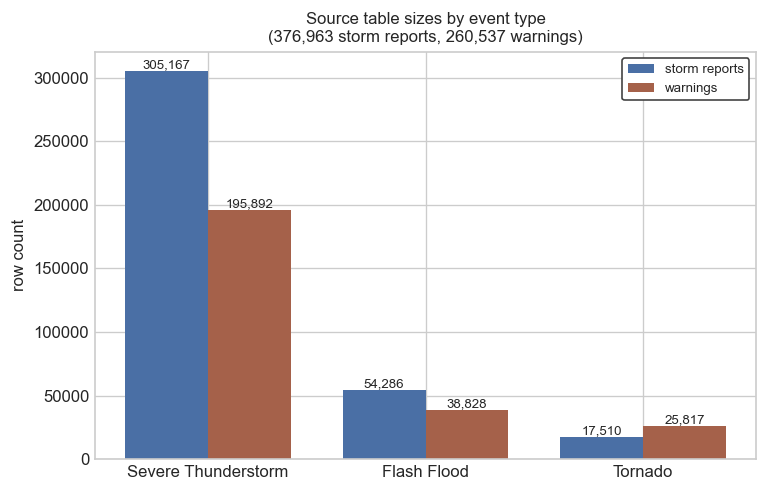

In [6]:
# Source table sizes: LSR vs warning counts by event type.
lsr_counts = stormreports["lsrtype"].value_counts().reindex(EVENT_ORDER)
wn_counts  = events["phenomena"].value_counts().reindex(EVENT_ORDER)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
xb = np.arange(len(EVENT_ORDER)); w = 0.38
ax.bar(xb - w/2, lsr_counts.values, w, color="#4a6fa5", label="storm reports")
ax.bar(xb + w/2, wn_counts.values,  w, color="#a5614a", label="warnings")
for i, (a, b) in enumerate(zip(lsr_counts.values, wn_counts.values)):
    ax.text(i - w/2, a, f"{a:,}", ha="center", va="bottom", fontsize=8)
    ax.text(i + w/2, b, f"{b:,}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(xb); ax.set_xticklabels([PHENOMENA_LABELS[t] for t in EVENT_ORDER])
ax.set_ylabel("row count")
ax.set_title(f"Source table sizes by event type\n({len(stormreports):,} storm reports, {len(events):,} warnings)", fontsize=10)
ax.legend(loc="upper right", **LEGEND_KW)
fig.tight_layout()
fig.savefig(IMG_DIR / "04_scope_sizes.png", dpi=120, bbox_inches="tight")
plt.show()

*Severe-thunderstorm rows outnumber tornado rows by more than an order of magnitude in both tables, and warnings are fewer than storm reports for every type. The disparity in sample size is why tornado estimates will carry the widest uncertainty and why the three types are never pooled.*

## Volume over the study span

Total warning volume per study year, 1 (2016) through 10 (2025), stacked by event type, so both the ten-year span and the per-type composition of each year are visible. Year-to-year shifts in volume are worth noting, since a change in how much weather occurred is a rival explanation the design must keep in view.

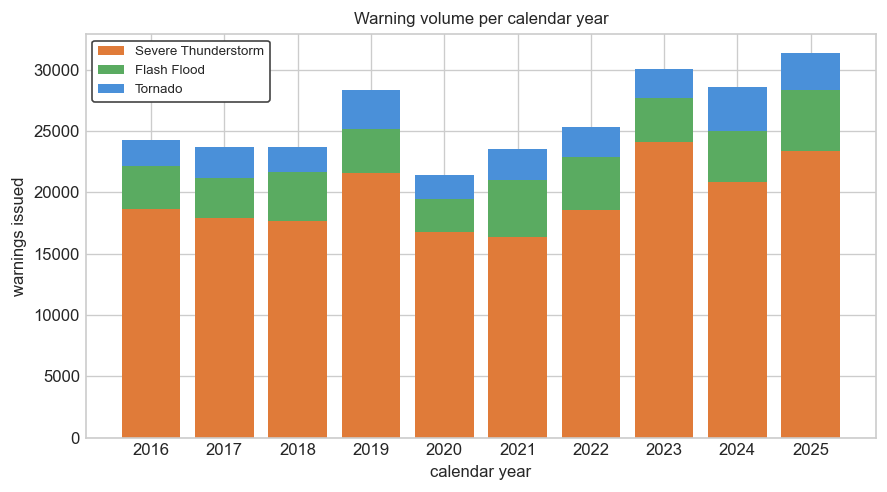

In [7]:
# Warnings per calendar year, stacked by event type.
from src.analysis.constants import study_year_to_calendar

def yearly_by_type(df, type_col):
    """Counts per study_year x event type, columns ordered SV/FF/TO, years 1-10."""
    return (df.groupby(["study_year", type_col]).size()
              .unstack(type_col).reindex(index=range(1, 11), columns=EVENT_ORDER).fillna(0))

counts = yearly_by_type(events, "phenomena")
cal = study_year_to_calendar(counts.index)   # study years 1-10 -> calendar 2016-2025
fig, ax = plt.subplots(figsize=(7.5, 4.2))
bottom = np.zeros(len(counts))
for t in EVENT_ORDER:
    ax.bar(cal, counts[t], bottom=bottom, color=PHENOMENA_COLORS[t], label=PHENOMENA_LABELS[t])
    bottom += counts[t].values
ax.set_xticks(cal); ax.set_xlabel("calendar year")
ax.set_ylabel("warnings issued"); ax.set_title("Warning volume per calendar year", fontsize=10)
ax.legend(loc="best", **LEGEND_KW)
fig.tight_layout()
fig.savefig(IMG_DIR / "04_scope_byyear.png", dpi=120, bbox_inches="tight")
plt.show()

*Every study year carries data for all three types, with no year missing or collapsing. Total volume fluctuates year to year as weather does; watch year 10 (2025) for any departure in volume, since a change in how much weather occurred competes with a change in performance.*

## Geographic distribution

Where the storm reports fall across the contiguous United States (CONUS), colored by event type. State outlines are drawn for reference (US Census 2022 boundaries, cached under `data/geo/`). The point cloud shows the spatial coverage the analysis rests on and the regional signature of each type: severe thunderstorms and tornadoes concentrate in the plains and southeast, flash floods spread more widely including the mountainous west. Points are plotted high-volume first so the sparser tornado reports remain visible on top.

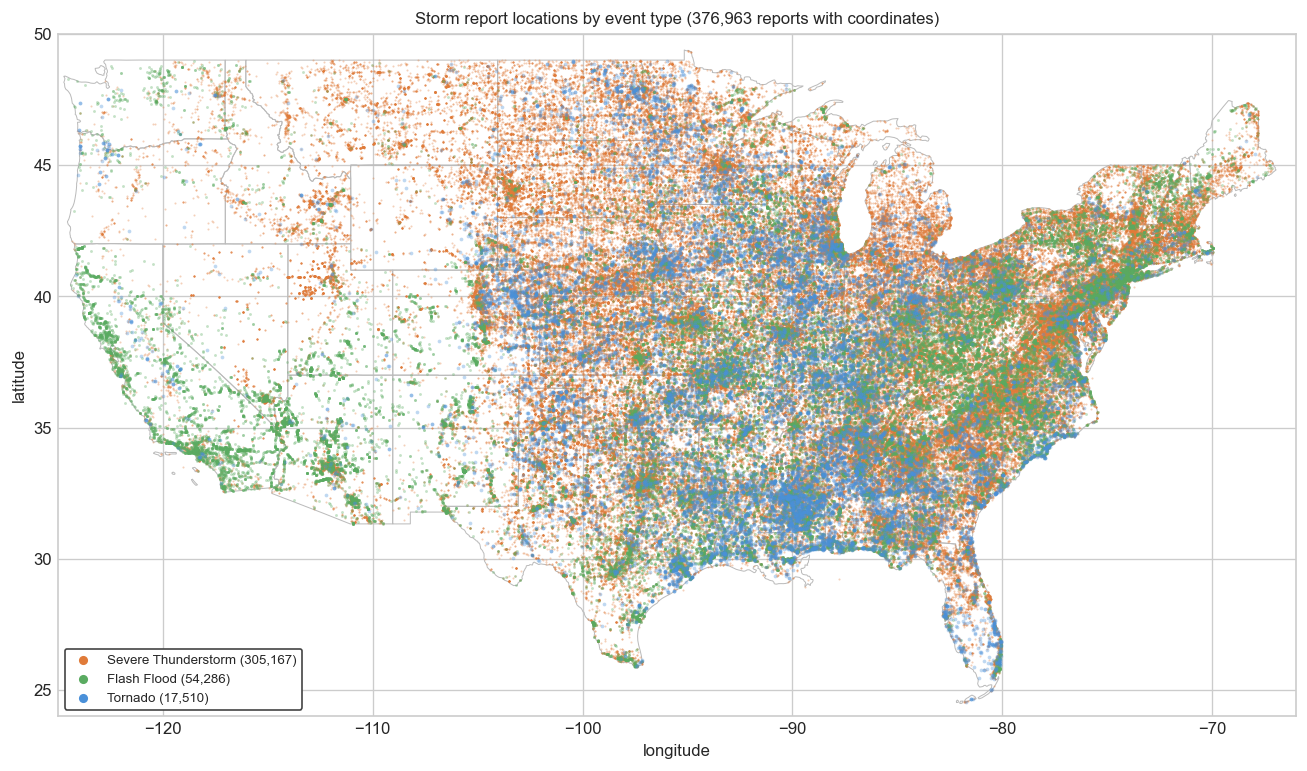

In [8]:
# Geographic distribution of storm reports across CONUS, colored by event type.
states = load_states(GEO_DIR)

fig, ax = plt.subplots(figsize=(11, 6.5))
states.boundary.plot(ax=ax, color="#bbb", linewidth=0.6, zorder=1)

# Plot high-volume types first so sparse tornado points stay visible on top.
# Color by PHENOMENA_COLORS (shared with every other plot); LSR_SIZES sets per-type point size.
sr = stormreports[stormreports["lon0"].notna() & stormreports["lat0"].notna()]
for t in ["SV", "FF", "TO"]:
    pts = sr[sr["lsrtype"] == t]
    ax.scatter(pts["lon0"], pts["lat0"], s=LSR_SIZES[t], c=PHENOMENA_COLORS[t],
               label=f"{PHENOMENA_LABELS[t]} ({len(pts):,})", alpha=0.35, linewidths=0, zorder=2)

ax.set_xlim(*CONUS_XLIM); ax.set_ylim(*CONUS_YLIM)
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.set_title(f"Storm report locations by event type ({len(sr):,} reports with coordinates)", fontsize=10)
leg = ax.legend(loc="lower left", fontsize=8, frameon=True, facecolor="white", edgecolor="#444", framealpha=1.0)
for h in leg.legend_handles:
    h.set_alpha(1.0); h.set_sizes([30])
fig.tight_layout()
fig.savefig(IMG_DIR / "04_scope_geographic.png", dpi=120, bbox_inches="tight")
plt.show()

*Reports cover the contiguous United States but not evenly: severe-storm and tornado reports cluster through the plains and southeast, flash-flood reports follow flood-prone terrain more broadly. The footprint is national, but the density is regional, which the coverage view below quantifies.*

## Warning volume by office

Where the Weather Forecast Offices (WFOs) sit and how much each one issued. The scatter above maps storm reports as points; this maps the 116 in-scope offices as one marker each, placed at the office's geocoded street address (US Census geocoder, with a ZIP-centroid fallback for the handful of airport and weather-station addresses that do not resolve at street level; the geocoded coordinates are a tracked input under `data/wfo/`, while the ZIP-centroid fallback table is cached under `data/geo/`). Marker area is proportional to the office's total warnings issued, all three event types pooled, so the figure shows how unevenly warning workload is distributed across the office network. This is the office-level companion to the report-level coverage view: a national rate is a volume-weighted average over these offices, and the biggest markers carry the most weight in it.

In [ ]:
# Warning volume by office: one marker per WFO, area proportional to total warnings.
wfo_coords = load_wfo_coords(WFO_DIR / "wfo_coords.csv", GEO_DIR, events["wfo"].unique())
plots.plot_wfo_volume(events, wfo_coords, states, IMG_DIR)

*Warning volume is markedly uneven across the office network: the largest markers cluster through the plains and the southeast, where severe-storm and tornado activity concentrates, while western and northeastern offices issue far fewer. A handful of high-volume offices dominate the national totals, so a national POD or FAR is effectively weighted toward them, the same concentration the report-level density maps show, now at the office level.*

## Matching-rule consistency

POD and FAR depend on how warnings were matched to storm reports: the spatial and intensity tolerances (`lsrbuffer`, `wind`, `hailsize`, `warningbuffer`) recorded in each file's COW (the IEM storm-based warning verification interface and this project's primary data source; the name is not an acronym) `params` block. These must be identical across all ten years. If a tolerance changed partway through, a shift in how matches are counted could masquerade as a real change in performance, and the year-10 finding would be an artifact. The check below reads the params from every raw collection file and confirms a single matching configuration governs the whole study span. It fails loudly otherwise.

In [10]:
from src.analysis.data import collect_matching_params, MATCHING_PARAMS

RAW_DIR = Path("../data/01_collection/COW")
params = collect_matching_params(RAW_DIR)

# Distinct matching configurations across all files; expect exactly one.
configs = params[MATCHING_PARAMS].drop_duplicates()
print(f"read {len(params):,} files spanning years {params['year'].min()}-{params['year'].max()} "
      f"({params['wfo'].nunique()} WFOs)")
print(f"distinct matching configurations: {len(configs)}")
print(configs.to_string(index=False))

# Also confirm every year carries that single configuration (no per-year drift).
per_year = params.groupby("year")[MATCHING_PARAMS].nunique().max().max()
assert len(configs) == 1 and per_year == 1, "Matching params vary across files/years; see `configs`."
print("\nmatching-rule consistency: PASS (one configuration across all years)")

read 1,342 files spanning years 2016-2026 (122 WFOs)
distinct matching configurations: 1
 lsrbuffer  wind  hailsize  warningbuffer
      15.0  58.0       1.0            1.0

matching-rule consistency: PASS (one configuration across all years)


## Missingness and clipping

What was missing or altered before the figures above. For each table: the share of rows with null coordinates, null outcome or lead-time values, and the share whose lead time was clipped at the 99th-percentile cap during cleaning (`leadtime_capped` / `lead0_capped`). The point is to tell the reader how much of what they are looking at is imputed, dropped, or capped, so the descriptive picture is read with the right caveats. The modeled columns themselves (`warned`, `verify`, `season_cat`, `study_year`) should show no nulls, since cleaning clips to the study span and asserts that.

In [11]:
# Missingness and clipping per table, as a share of rows.
def pct(mask):
    return round(100 * mask.mean(), 2)

sr_warned = stormreports[stormreports["warned"] == 1]   # lead time only defined on warned LSRs
storm_q = {
    "rows":              len(stormreports),
    "null coords %":     pct(stormreports["lon0"].isna() | stormreports["lat0"].isna()),
    "null leadtime %":   pct(sr_warned["leadtime"].isna()),
    "leadtime capped %": pct(stormreports["leadtime_capped"] == 1),
    "null season_cat %": pct(stormreports["season_cat"].isna()),
    "null warned %":     pct(stormreports["warned"].isna()),
}
ev_verified = events[events["verify"] == 1]             # lead0 reported on verified warnings
event_q = {
    "rows":              len(events),
    "null coords %":     float("nan"),                  # events are areas (carea), not points
    "null leadtime %":   pct(ev_verified["lead0"].isna()),
    "leadtime capped %": pct(events["lead0_capped"] == 1),
    "null season_cat %": pct(events["season_cat"].isna()),
    "null verify %":     pct(events["verify"].isna()),
}

quality = pd.DataFrame({"stormreports": storm_q, "events": event_q})
print(quality.to_string())

                   stormreports     events
rows                  376963.00  260537.00
null coords %              0.00        NaN
null leadtime %            0.00       0.00
leadtime capped %          0.75       0.46
null season_cat %          0.00       0.00
null warned %              0.00        NaN
null verify %               NaN       0.00


*Modeled columns are clean: no nulls in outcomes, season, or study year. Coordinates are essentially complete for storm reports (events are areas, not points, so coordinate nullity does not apply). Lead-time clipping touches under 1% of rows in each table, so the 99th-percentile cap shapes only the extreme tail.*

## Modeling gate: can the nine fits be estimated?

Before any modeling, one check: is each planned fit estimable? Every model carries a `C(season_cat)` term, and a logistic fit fails if any season cell sits at exactly 0% or 100% outcome (complete separation) or is too thin to estimate (here, fewer than 30 rows). The table below is the verdict, one row per event type and metric (nine rows). `PASS` means no separation and no thin cell; anything else is flagged and carried into how that model is read in `05_analysis`. The per-season structure itself, the rates and the seasonal gradient, is shown in the figure that follows; this table only certifies the data can support the fits. Lead time is continuous, so its check is a minimum group size rather than a rate.

In [12]:
from src.analysis.stats import cell_summary

SEASON_ORDER = ["Spring", "Summer", "Fall", "Winter"]

# One verdict row per (event type, metric): smallest season cell, any separation, PASS/FLAG.
# POD/FAR are binary rates (separation possible); LTA is continuous (size check only).
def verdict_row(t, metric, df, type_col, outcome_col, binary):
    sub = df[df[type_col] == t]
    if binary:
        s = cell_summary(sub, "season_cat", outcome_col).reindex(SEASON_ORDER)
        sep = (s["rate"].isin([0.0, 1.0])).any()
        min_cell = int(s["n"].min())
    else:  # LTA: warned LSRs only, group sizes per season
        sub = sub[sub["warned"] == 1]
        min_cell = int(sub.groupby("season_cat").size().reindex(SEASON_ORDER).min())
        sep = False
    flagged = sep or min_cell < 30
    return {"event_type": t, "metric": metric, "n": len(sub), "min_cell_n": min_cell,
            "separation": "yes" if sep else "no", "status": "FLAG" if flagged else "PASS"}

# FAR shares the verify column: separation on verify is identical to separation on 1 - verify.
rows = []
for t in PHENOMENA:
    rows.append(verdict_row(t, "POD", stormreports, "lsrtype",  "warned", binary=True))
    rows.append(verdict_row(t, "FAR", events,       "phenomena", "verify", binary=True))
    rows.append(verdict_row(t, "LTA", stormreports, "lsrtype",  None,     binary=False))

gate = pd.DataFrame(rows)
print(gate.to_string(index=False))
print(f"\n{(gate['status'] == 'PASS').sum()}/{len(gate)} fits estimable (PASS)")

event_type metric      n  min_cell_n separation status
        TO    POD  17510        1996         no   PASS
        TO    FAR  25817        3086         no   PASS
        TO    LTA  11217        1198         no   PASS
        SV    POD 305167       13386         no   PASS
        SV    FAR 195892        7261         no   PASS
        SV    LTA 234086        9166         no   PASS
        FF    POD  54286        5634         no   PASS
        FF    FAR  38828        1936         no   PASS
        FF    LTA  42529        3145         no   PASS

9/9 fits estimable (PASS)


*All nine fits pass: no season cell is fully separated (0% or 100%) and the smallest cell holds well over a thousand rows, so every `C(season_cat)` term is estimable. The gate is green; the modeling in `05_analysis` rests on data that can support it.*

## Reporting seasonality

When in the year each event type is reported, as a monthly profile pooled across 2016 to 2025. Each line is one phenomenon's share of its own annual storm reports by calendar month, so the line sums to 100% across the twelve months and the three types are directly comparable on the same axis. This shows the seasonal signature of reporting, tornado and severe-storm reporting peaking in the warm season, flash-flood reporting spread through summer, which is the structure the `C(season_cat)` term in each model is there to absorb.

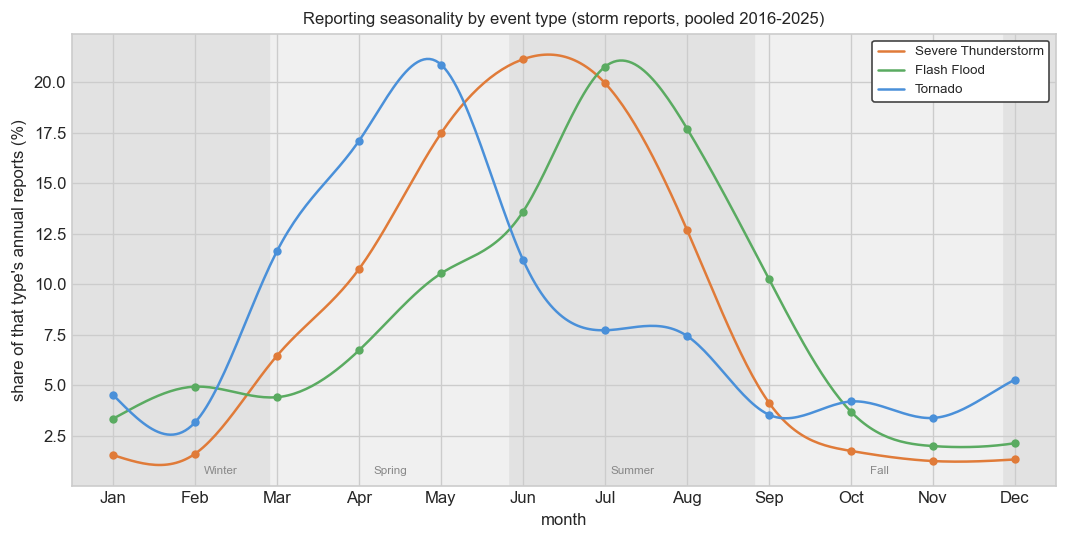

In [13]:
# Monthly reporting seasonality: each phenomenon's share of its own reports by month.
from scipy.interpolate import make_interp_spline

EVENT_ORDER = ["SV", "FF", "TO"]   # high-volume to low-volume
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

sr = stormreports.copy()
sr["month"] = sr["valid"].dt.month

# Count by month x type, then normalize within each type so a line sums to 100% over the year.
monthly = (sr.groupby(["month", "lsrtype"]).size()
             .unstack("lsrtype").reindex(index=range(1, 13), columns=EVENT_ORDER).fillna(0))
share = monthly.div(monthly.sum(axis=0), axis=1) * 100   # percent of each type's annual reports

def cyclic_spline(y):
    """Smooth a 12-month cyclic series; pad with wrap-around months for seamless Jan/Dec edges."""
    xp = np.arange(0, 14)                           # Dec(0), Jan(1)..Dec(12), Jan(13)
    yp = np.concatenate([[y[-1]], y, [y[0]]])       # 14 values to match xp
    xs = np.linspace(1, 12, 300)
    ys = make_interp_spline(xp, yp, k=3)(xs)
    return xs, np.clip(ys, 0, None)                 # clip overshoot below 0

# Engineered season_cat windows break on the 27th (treatment-anniversary anchored), not the
# 1st, so boundaries land mid-month: month + 26/days. On the 1-12 month axis Feb 27 ~ 2.87,
# May 27 ~ 5.87, Aug 27 ~ 8.87, Nov 27 ~ 11.87. Winter wraps both ends of the axis.
SEASON_BOUNDS = [2 + 26/28, 5 + 26/31, 8 + 26/31, 11 + 26/30]   # Spring, Summer, Fall, Winter starts
SEASON_GREYS = {"Spring": "#f0f0f0", "Summer": "#e2e2e2", "Fall": "#f0f0f0", "Winter": "#e2e2e2"}

fig, ax = plt.subplots(figsize=(9, 4.6))
# Shade the four engineered seasons behind the lines (alternating faint grey); Winter wraps.
sp, su, fa, wi = SEASON_BOUNDS
ax.axvspan(0.5, sp, color=SEASON_GREYS["Winter"], zorder=0)   # Winter (head, before Feb 27)
ax.axvspan(sp, su,  color=SEASON_GREYS["Spring"], zorder=0)
ax.axvspan(su, fa,  color=SEASON_GREYS["Summer"], zorder=0)
ax.axvspan(fa, wi,  color=SEASON_GREYS["Fall"],   zorder=0)
ax.axvspan(wi, 12.5, color=SEASON_GREYS["Winter"], zorder=0)  # Winter (tail, after Nov 27)
for xc, name in zip([(0.5+sp)/2 + 0.6, (sp+su)/2, (su+fa)/2, (fa+wi)/2, (wi+12.5)/2 - 0.2],
                    ["Winter", "Spring", "Summer", "Fall", ""]):
    ax.text(xc, ax.get_ylim()[1], name, ha="center", va="top", fontsize=7, color="#888", zorder=1)
for t in EVENT_ORDER:
    y = share[t].values
    xs, ys = cyclic_spline(y)
    ax.plot(xs, ys, color=PHENOMENA_COLORS[t], label=PHENOMENA_LABELS[t], zorder=3)
    ax.plot(range(1, 13), y, "o", ms=4, color=PHENOMENA_COLORS[t], zorder=3)   # actual monthly points
ax.set_xlim(0.5, 12.5)
ax.set_xticks(range(1, 13)); ax.set_xticklabels(MONTHS)
ax.set_xlabel("month"); ax.set_ylabel("share of that type's annual reports (%)")
ax.set_title("Reporting seasonality by event type (storm reports, pooled 2016-2025)", fontsize=10)
ax.legend(loc="upper right", fontsize=8, frameon=True, facecolor="white", edgecolor="#444", framealpha=1.0)
fig.tight_layout()
fig.savefig(IMG_DIR / "04_reporting_seasonality.png", dpi=120, bbox_inches="tight")
plt.show()

*Each type has a distinct seasonal signature: tornado and severe-storm reporting peaks in spring and summer, flash-flood reporting concentrates in the warm season but spreads wider. This is the within-year structure the `C(season_cat)` term absorbs so that the study-year and year-10 terms are read net of season. The shaded bands mark the four engineered seasons; note they break on the 27th of February, May, August, and November (anchored to the treatment anniversary), not on the 1st, so the boundaries sit slightly past each month tick and Winter wraps both ends of the year.*

## LTA distribution

The shape of the lead-time (LTA) outcome, one figure per event type, over warned storm reports only. LTA is the one continuous metric and its model is OLS, so its distribution matters: expect a strong right skew, a pile-up at zero (warnings issued at or after the event), and a hard right edge from the 99th-percentile cap applied in cleaning. The skew is why summaries elsewhere use the median, and it is why the LTA OLS residuals will need a look (a transform may be warranted) in `05_analysis`. In each figure the dashed line marks the median, the dotted line the mean, so the gap between them reads directly.

### LTA distribution: Severe Thunderstorm

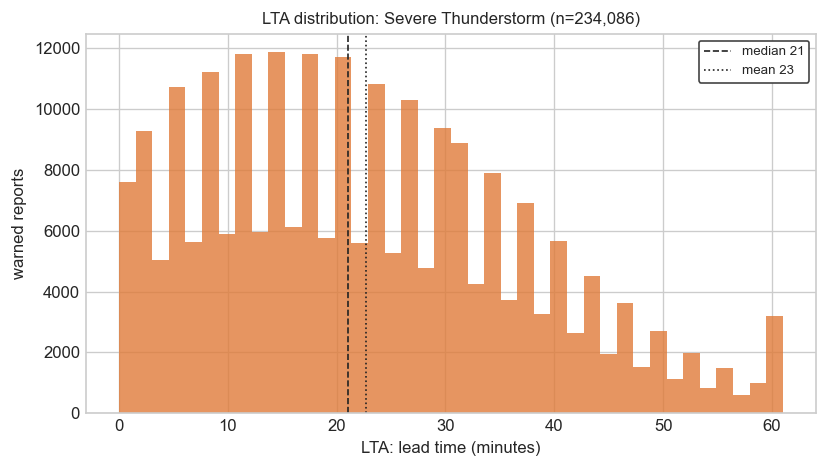

In [14]:
plots.plot_lta_dist(stormreports, "SV", IMG_DIR)

*Severe-storm lead times center in the low 20s of minutes with the expected right skew; mean sits above median, pulled by the long tail. Comfortably the largest LTA sample of the three types.*

### LTA distribution: Flash Flood

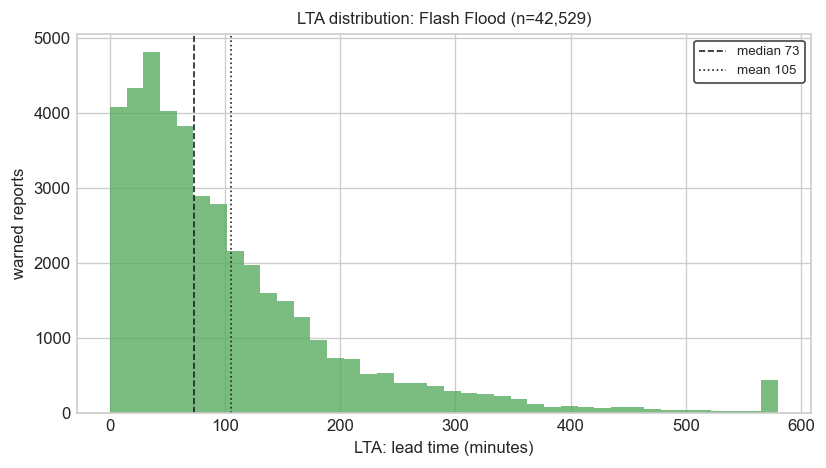

In [15]:
plots.plot_lta_dist(stormreports, "FF", IMG_DIR)

*Flash-flood lead times run an order of magnitude longer (tens to over a hundred minutes) and skew hardest of the three; the median-mean gap is widest here, which is why FF most needs the median summary and the closest residual check under OLS.*

### LTA distribution: Tornado

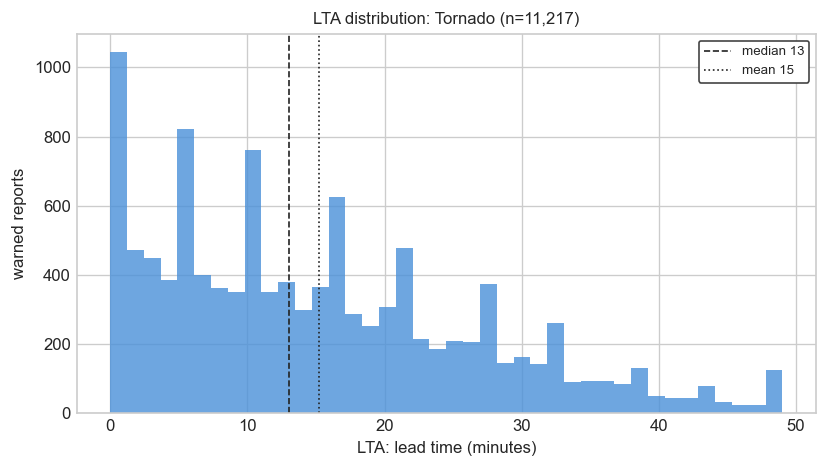

In [16]:
plots.plot_lta_dist(stormreports, "TO", IMG_DIR)

*Tornado lead times are the shortest, mostly under 15 minutes, reflecting how little warning the phenomenon allows. The smallest LTA sample, so its yearly summaries will be the noisiest.*

## Spatial coverage and concentration

The scatter above shows where reports fall; this asks how evenly. A binned density (hexbin) per event type over CONUS, one figure each, log-colored because counts are heavily concentrated. The takeaway across the three: the national estimate is not drawn evenly from the map. A handful of high-volume regions dominate, so a national POD or FAR is really a volume-weighted average over those regions, and a change in one busy region can move the national number more than a change spread thin elsewhere.

### Coverage density: Severe Thunderstorm

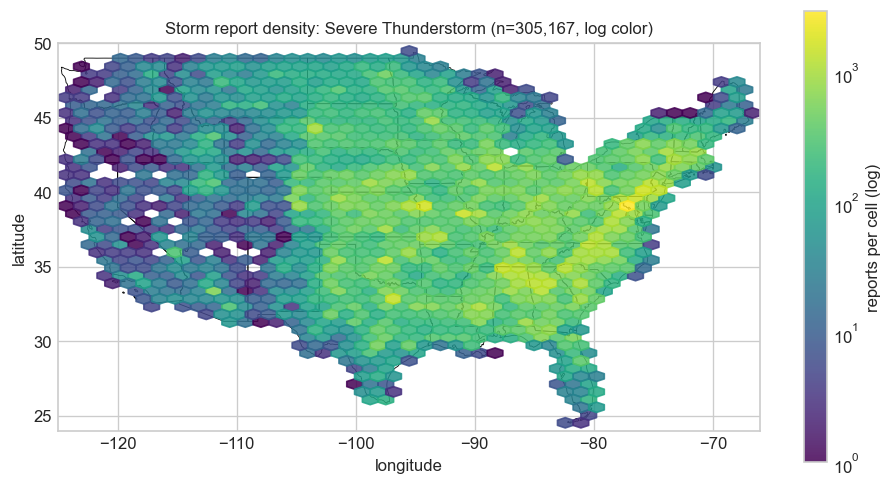

In [17]:
states = load_states(GEO_DIR)   # CONUS outlines, loaded once for the three coverage figures
plots.plot_coverage(stormreports, states, "SV", IMG_DIR)

*Severe-storm density is broad but peaks across the plains and the southeast; the densest cells hold orders of magnitude more reports than the sparse west, hence the log scale.*

### Coverage density: Flash Flood

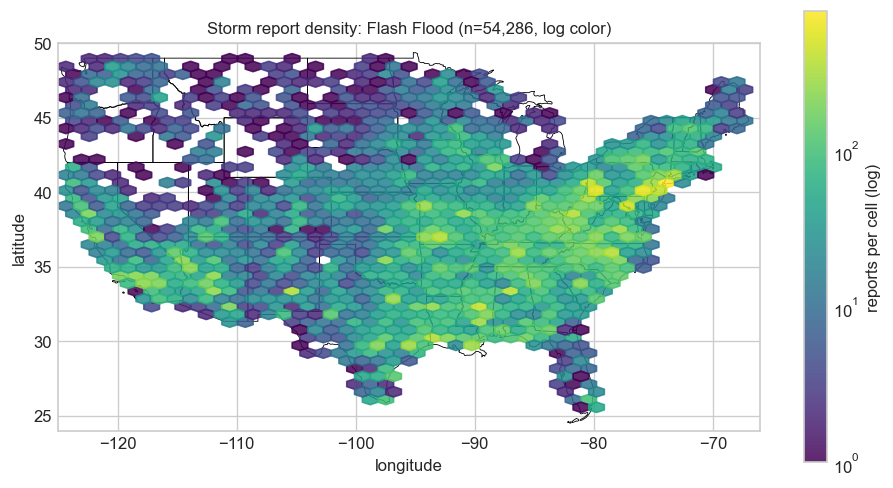

In [18]:
plots.plot_coverage(stormreports, states, "FF", IMG_DIR)

*Flash-flood density spreads more widely, following flood-prone terrain into the east and the mountainous west rather than concentrating in a single corridor.*

### Coverage density: Tornado

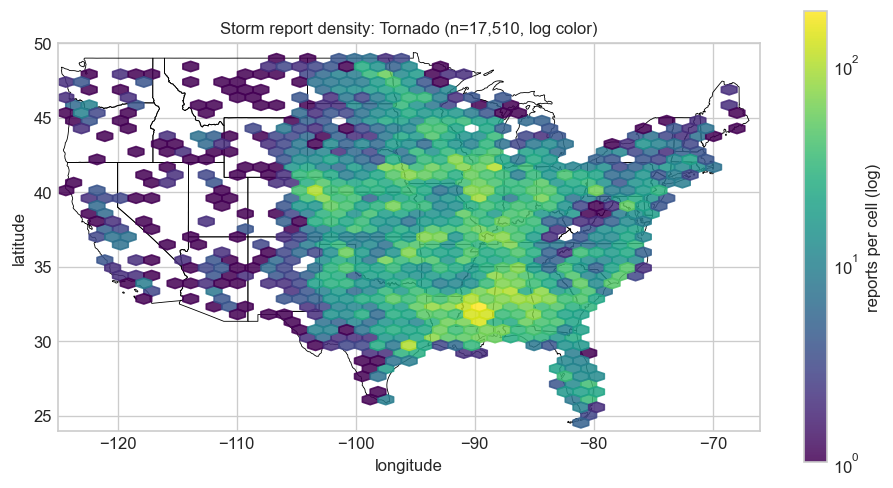

In [19]:
plots.plot_coverage(stormreports, states, "TO", IMG_DIR)

*Tornado density concentrates most tightly, through the classic tornado-alley and dixie-alley corridors, with the sparsest national coverage of the three. The national tornado estimate leans hardest on a few regions.*

## Year-10 geographic composition

The coverage maps above pool all ten years. But the study is a year-10 before/after comparison, and a shift in *where* reports came from is a rival explanation for any national POD or FAR move: if year 10 drew its reports from a different regional mix than the 2016-2024 baseline, the national rate can change through composition alone, with no change in performance. The three figures below check this directly. For each event type, both periods are binned on one identical CONUS grid, each cell is expressed as a share of its own period's national total, and the difference is mapped (year-10 share minus baseline share). Red marks cells that drew a larger share of reports in year 10, blue a smaller share; a near-uniform pale map means the footprint held steady. Shares (not raw counts) are used so this isolates distribution shift independent of total volume, which the volume-by-year figure already covers. With only one year of year-10 data the grid is kept coarse and sparse cells are noisy, so this reads as broad regional shift or not, not cell-level precision.

### Year-10 composition: Severe Thunderstorm

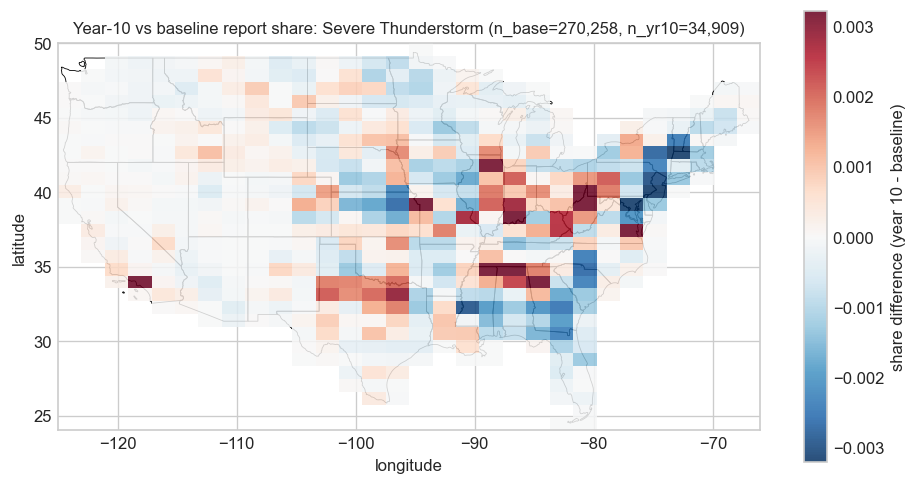

In [20]:
plots.plot_coverage_diff(stormreports, states, "SV", IMG_DIR)

*Per-cell share differences are small in magnitude (under about 1%, max 1.2%), which is partly mechanical: spreading some 35,000 year-10 reports across roughly 500 cells makes any single cell's share tiny. But they are not noise. The differences are spatially coherent (Moran's I about +0.31, far above the zero expected of salt-and-pepper scatter), and far more cells move than one year of sampling can explain (about 54% exceed two sampling standard deviations, against the roughly 5% expected by chance). So the year-10 severe-storm footprint did shift relative to baseline in a structured, regional way. This says nothing causal: year-to-year geographic shifts are normal as weather moves around, and the baseline surely wobbles this much itself. The takeaway for the design is that geographic composition is a live rival explanation for any national year-10 rate move, not one the map lets us dismiss.*

### Year-10 composition: Flash Flood

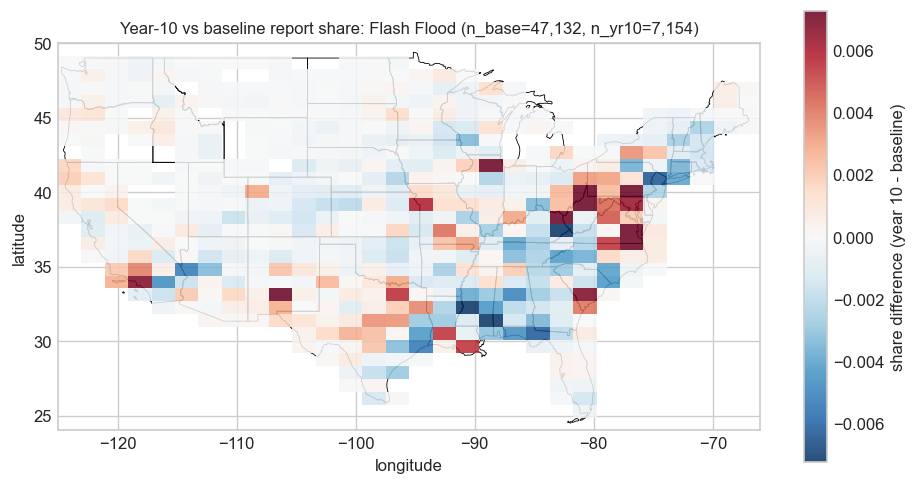

In [21]:
plots.plot_coverage_diff(stormreports, states, "FF", IMG_DIR)

*Flash flood shows the same picture and a touch stronger per-cell: differences reach about 2.8% in the busiest cells, are spatially coherent (Moran's I about +0.27), and roughly 49% of cells exceed two sampling standard deviations, again far above the 5% chance rate. The year-10 flash-flood footprint shifted regionally relative to baseline. As with severe storms this is not evidence of anything causal; flood-prone weather simply concentrated differently in 2025 than in the baseline average. But it confirms that geographic composition is a live confound for the FF metrics too, not a footprint that held steady.*

### Year-10 composition: Tornado

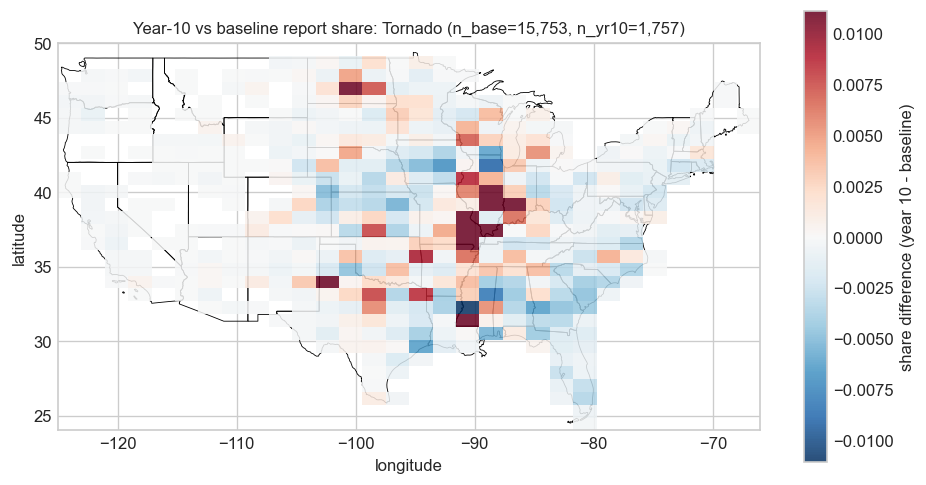

In [22]:
plots.plot_coverage_diff(stormreports, states, "TO", IMG_DIR)

*Tornado is the sparsest map, just 1,757 year-10 reports over about 260 cells, so individual cells are genuinely noisy and should not be read one by one. Even so the same signal holds at the map level: the differences are spatially coherent (Moran's I about +0.30) and about 31% of cells exceed two sampling standard deviations, well above the 5% chance rate, so the regional shift is real rather than scatter, just less sharply resolved than for the higher-volume types. The reading is the same as for severe storm and flash flood: the year-10 tornado footprint moved relative to baseline, this is ordinary year-to-year weather variation rather than anything causal, and it leaves geographic composition as a live confound that the year-10 tornado estimate, already the most uncertain, cannot rule out on its own.*

## Baseline variability

How much each metric naturally moves from year to year, before any year-10 comparison. One figure per metric (POD, FAR, LTA), showing the value for each baseline year 2016 to 2024 as points, with each event type's baseline mean (dashed) and a shaded band of plus or minus one standard deviation. FAR is plotted as `1 - verify`, so higher means more false alarms; LTA uses the yearly median given the lead-time skew. The point is to set the reader's expectation for noise: a metric wobbles every year just from weather and reporting chance, so a year-10 move only matters if it clears this normal wobble. Year 10 (2025) is deliberately left off here; this is the baseline spread it will be judged against in `05_analysis`. A wide band means a noisy metric where only a large year-10 change would convince; a narrow band means even a modest change would stand out.

### Baseline variability: POD

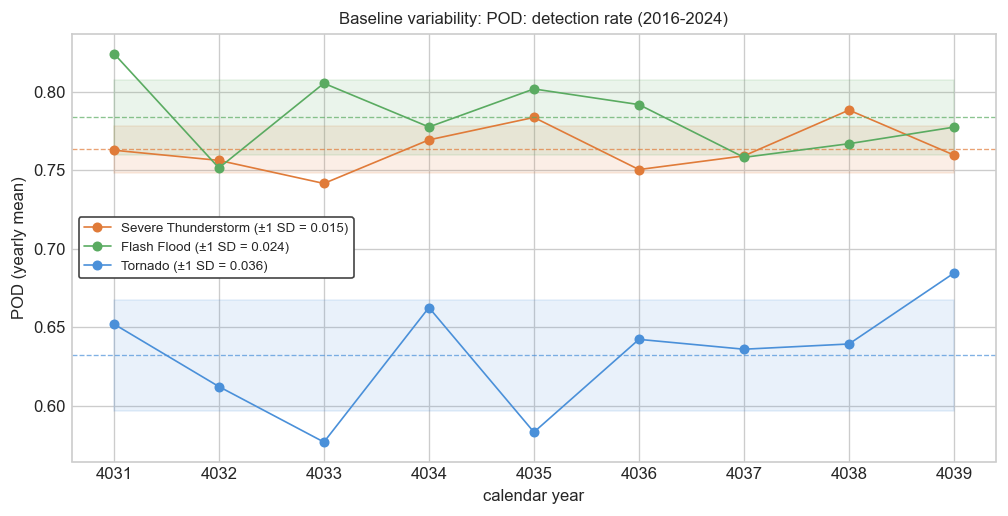

In [23]:
# Per-year baseline series for each metric (2016-2024); FAR = 1 - verify, LTA = median lead time.
from src.analysis.stats import baseline_yearly

BASELINE_YEARS = range(2016, 2025)
warned = stormreports[stormreports["warned"] == 1]

def pod_series():
    return {t: baseline_yearly(stormreports[stormreports["lsrtype"] == t], "warned",
                               agg="mean", years=BASELINE_YEARS) for t in EVENT_ORDER}

def far_series():
    return {t: 1 - baseline_yearly(events[events["phenomena"] == t], "verify",
                                   agg="mean", years=BASELINE_YEARS) for t in EVENT_ORDER}

def lta_series():
    return {t: baseline_yearly(warned[warned["lsrtype"] == t], "leadtime",
                               agg="median", years=BASELINE_YEARS) for t in EVENT_ORDER}

plots.plot_baseline_variability(pod_series(), "POD: detection rate",
                                "POD (yearly mean)", BASELINE_YEARS, "pod", IMG_DIR)

*Detection rates sit at clearly separate levels by type and wobble modestly across the baseline. Tornado POD is the noisiest band (smallest sample); severe-storm POD is the tightest. The band sets the bar: a year-10 POD move inside it is unremarkable, outside it is notable.*

### Baseline variability: FAR

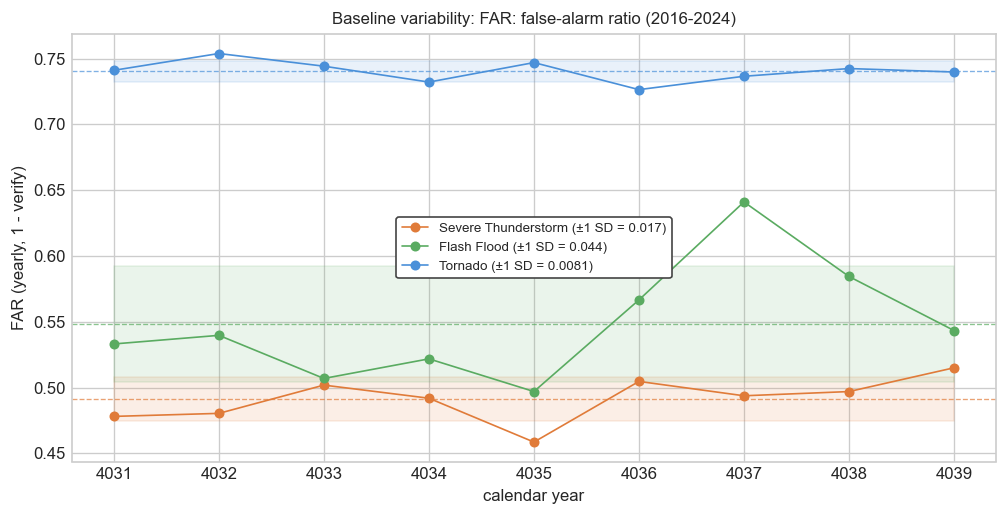

In [24]:
plots.plot_baseline_variability(far_series(), "FAR: false-alarm ratio",
                                "FAR (yearly, 1 - verify)", BASELINE_YEARS, "far", IMG_DIR)

*Tornado false-alarm ratio is the highest and steadiest; severe-storm FAR is tight; flash-flood FAR is the noisiest band of the three (smallest warning sample), so an FF year-10 FAR change must be sizeable to clear the normal wobble.*

### Baseline variability: LTA

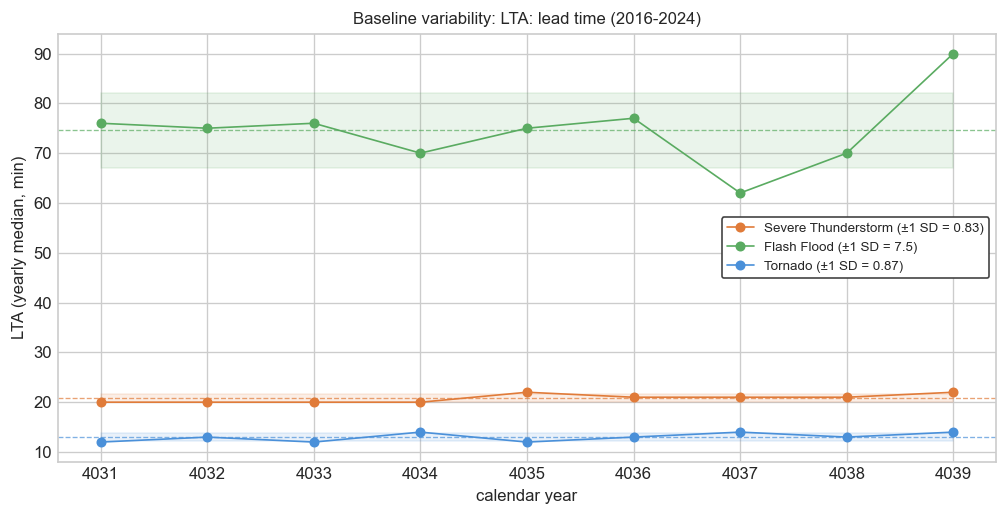

In [25]:
plots.plot_baseline_variability(lta_series(), "LTA: lead time",
                                "LTA (yearly median, min)", BASELINE_YEARS, "lta", IMG_DIR)

*Median lead times separate by an order of magnitude (flash flood far above tornado and severe storm) and each wobbles year to year within a band. As with the other metrics, the band is the reference a year-10 LTA change must clear to be read as more than noise.*

## Why we measure against the trend, not the flat mean

The variability bands above set up one yardstick for a year-10 move: the flat baseline mean, with a move judged by how far it clears the band. But if a metric drifts across the baseline years, the flat mean is the wrong reference. The honest expectation for year 10 is not the average baseline year; it is where the baseline trend would land.

The figure below makes this concrete using the metric that drifts most clearly across the baseline, severe-storm lead time (the steepest season-adjusted slope and the tightest fit of the nine series). It is baseline-only: study years 1 to 9, with no year-10 data and no extension to year 10. The points are the raw yearly means. The solid line is the season-adjusted trend, its slope equal to the `study_year` coefficient from `leadtime ~ C(season_cat) + study_year` (drift net of season mix, the same quantity `05_analysis` reads). The dotted line is that same trend evaluated at the mean baseline year, so the flat mean and the trend share one model and one level; only the slope separates them. Means (not medians) are plotted because the line mirrors an OLS model, which is about means.

The two lines diverge across the baseline span: that divergence is the drift a flat-mean comparison ignores. This is exactly why the `05_analysis` model carries `study_year` alongside `is_year10`: the trend term absorbs the drift so the year-10 indicator measures departure from the trend, not from a flat average. The year-10 verdict itself belongs to `05_analysis`.


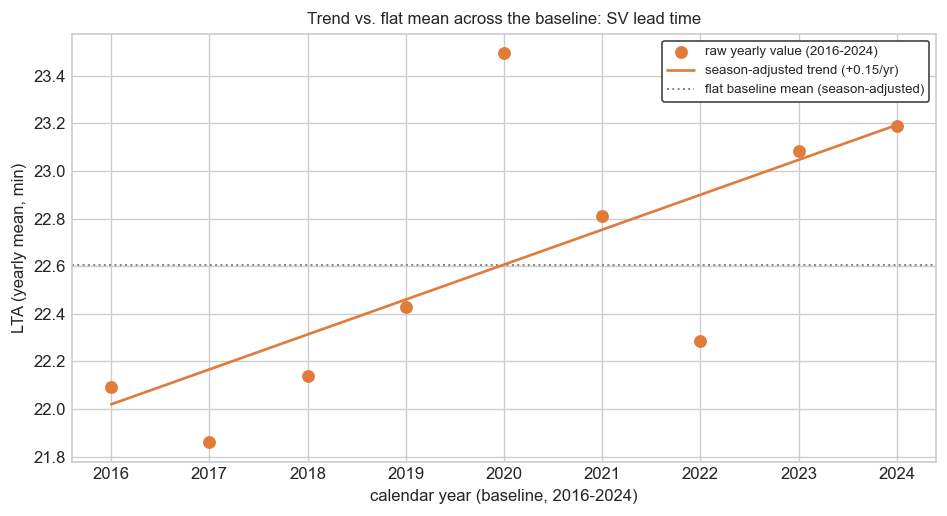

In [26]:
# Trend-vs-flat-mean yardstick, SV lead time: raw yearly means, season-adjusted trend.
from src.analysis.stats import season_adjusted_trend

sv_warned = warned[warned["lsrtype"] == "SV"]
sv_raw    = baseline_yearly(sv_warned, "leadtime", year_col="study_year",
                            agg="mean", years=range(1, 10))
sv_trend  = season_adjusted_trend(sv_warned, "leadtime")

plots.plot_baseline_trend(sv_raw, sv_trend, "SV", "SV lead time",
                          "LTA (yearly mean, min)", "lta_sv", IMG_DIR)

*Severe-storm lead time drifts up across the baseline at about 0.15 minutes per year (net of season). The trend line crosses the flat baseline mean near the middle of the span, running below it in the early years and above it in the late years, while the yearly means scatter around the trend as a noisy fit. That growing separation toward the ends is the drift a flat-mean comparison would ignore. The other eight series drift less, but the same logic applies: `05_analysis` reads the year-10 departure against the trend line, not the flat mean, so ordinary baseline drift is not mistaken for a year-10 effect.*

## Does OLS hold for lead time?

The LTA model is the one OLS fit (POD and FAR are logistic), and OLS rests on roughly normal, even-variance residuals. The LTA distributions above showed the raw outcome is right-skewed, but skew in the raw outcome is not itself an OLS problem; skew in the model *residuals* is. So this section fits the baseline LTA model, `f(leadtime) ~ C(season_cat) + study_year` on study years 1 to 9, and asks which outcome transform leaves the residuals closest to normal. Three candidates are compared per event type: raw minutes, `log1p` (log of minutes plus one, to absorb the small zero mass), and `sqrt`. The figures are residual quantile-quantile (Q-Q) plots: points on the dashed 45-degree line mean normal residuals, and the skew of each transform is printed in the legend. This is baseline-only and diagnostic, with no year-10 data, so the modeling choice for `05_analysis` is settled here rather than discovered mid-analysis. Lead-time zeros (warnings issued at or after the event) are a small share in every type, so the question is ordinary skew, not a spike at zero.

### LTA residuals: Severe Thunderstorm

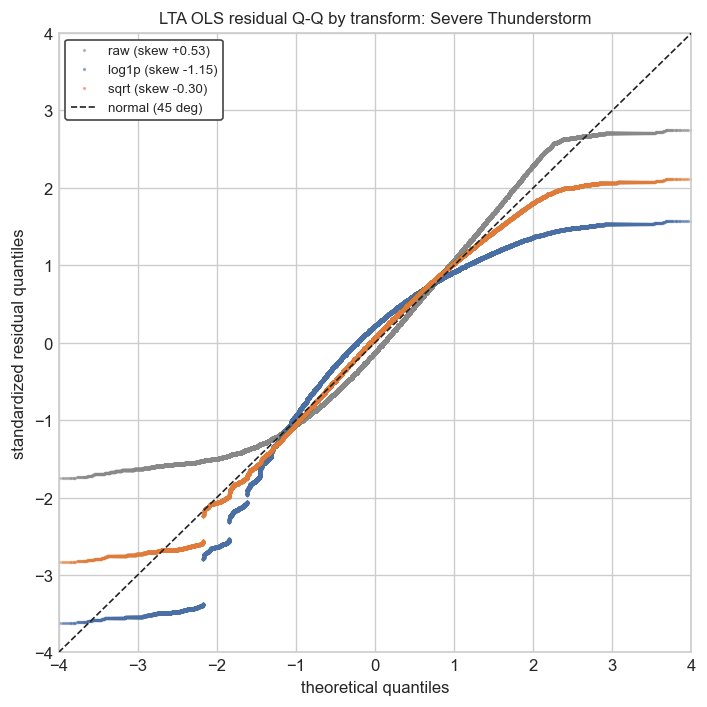

In [27]:
# LTA OLS residual Q-Q, raw vs log1p vs sqrt, baseline years; one figure per event type.
from src.analysis.stats import lta_residuals

def lta_resid_set(t):
    """Residuals (and skew) of the baseline LTA model under each transform, for type t."""
    d = warned[warned["lsrtype"] == t]
    return {tf: lta_residuals(d, tf) for tf in ["raw", "log1p", "sqrt"]}

plots.plot_lta_residual_qq(lta_resid_set("SV"), "SV", IMG_DIR)

*Severe-storm residuals are mildly right-skewed under raw minutes (skew +0.53). `log1p` overcorrects into a left skew (-1.15); `sqrt` lands closest to normal (-0.30) and tracks the 45-degree line best through the body of the distribution.*

### LTA residuals: Flash Flood

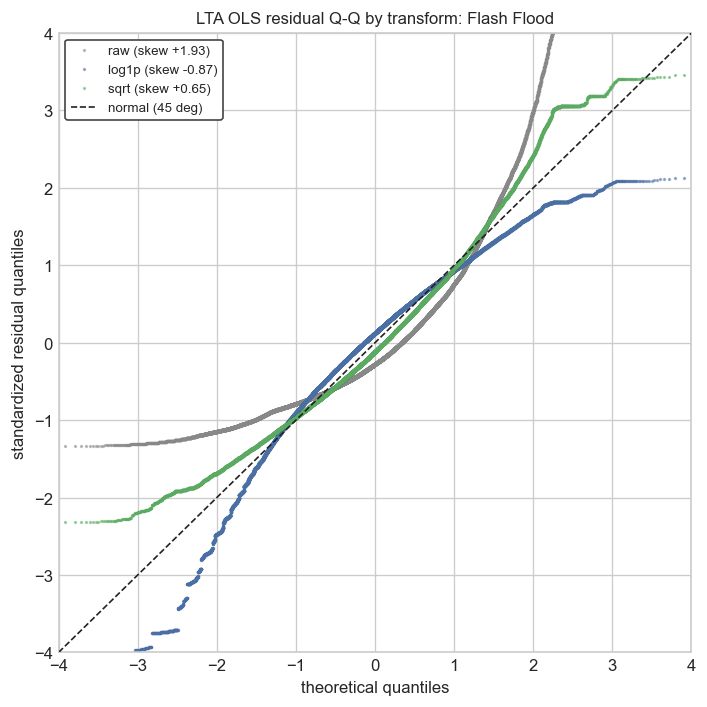

In [28]:
plots.plot_lta_residual_qq(lta_resid_set("FF"), "FF", IMG_DIR)

*Flash flood is the hardest case: raw residuals are strongly right-skewed (+1.93), the worst of the three types. `log1p` again overshoots to the left (-0.87), while `sqrt` more than halves the raw skew (+0.65) and is the only transform whose right tail does not run away from the line. Not perfectly normal, but clearly the best behaved and the most defensible single choice.*

### LTA residuals: Tornado

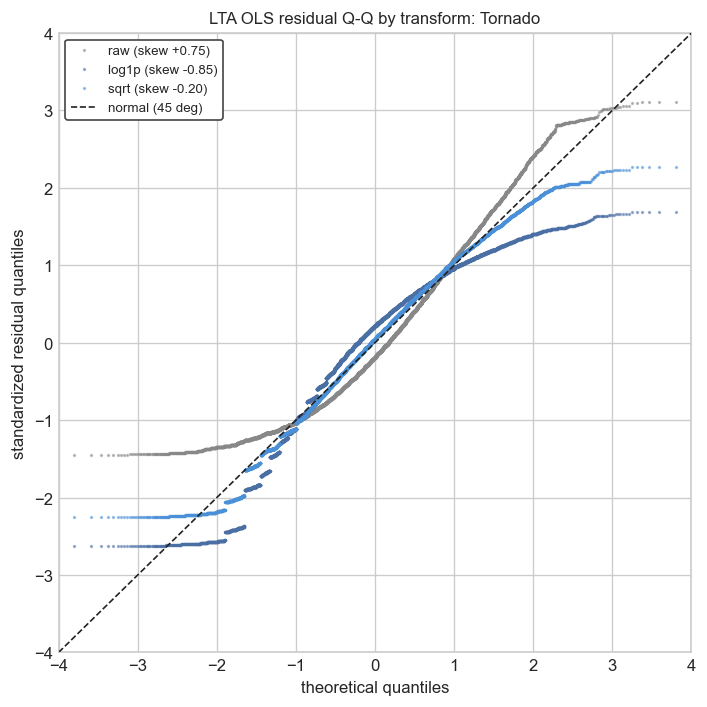

In [29]:
plots.plot_lta_residual_qq(lta_resid_set("TO"), "TO", IMG_DIR)

*Tornado shows the same pattern: raw right-skewed (+0.75), `log1p` overcorrected (-0.85), `sqrt` closest to normal (-0.20). The smallest LTA sample, so its Q-Q is the noisiest, but the ordering is unambiguous and matches the other two types.*

### Decision for `05_analysis`

`sqrt(leadtime)` is the residual-best transform for all three event types, and `log1p` overcorrects every time. So the LTA model in `05_analysis` is fit as `sqrt(leadtime) ~ C(season_cat) + study_year + is_year10`, one transform applied uniformly across event types. The consequence to carry forward: the `study_year` and `is_year10` coefficients are then on the square-root-of-minutes scale, not minutes, so they are back-transformed to minutes (at a representative baseline level) for reporting the effect size. POD and FAR are unaffected; this concerns the LTA fits only.